<a href="https://colab.research.google.com/github/SonuDixit/Math_examples/blob/main/AutoEncoder_SVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Truncated SVD is best low rank approximation
2. Compare it with AutoEncoder - have non-linearity

Consider a dummy dataset.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import layers, losses
import matplotlib.pyplot as plt

np.random.seed(1)

In [2]:
class Autoencoder(Model):
  def __init__(self, latent_dim, input_dim):
    super(Autoencoder, self).__init__()
    self.latent_dim = latent_dim   
    self.encoder = tf.keras.Sequential([
      layers.Dense(latent_dim, activation='tanh'),
    ])
    self.decoder = tf.keras.Sequential([
      layers.Dense(input_dim)
    ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

In [3]:
input_dim = 20
latent_dim = 5
data_points = 200


In [4]:
data = np.random.uniform(low=-5.0,high=5.0, size=(data_points, input_dim))
print(data.shape)

(200, 20)


In [5]:
autoencoder = Autoencoder(input_dim =input_dim,latent_dim = input_dim)
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

In [6]:
history = autoencoder.fit(data,data,epochs=2000, verbose=0)


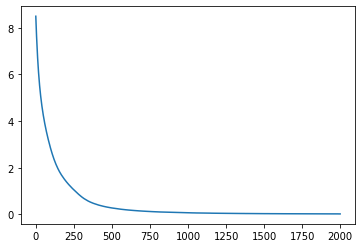

In [7]:
plt.plot(history.history['loss'])

Reconstruction loss (MSE) is ~0 in case of AutoEncoder.  
Check the minimum possible error, if using linear approximation.  
$D = U \Sigma V^T : D \in \Re^{n\times m}, U \in \Re^{n\times n}, \Sigma \in \Re^{n\times m}, V \in \Re^{m\times m}$.  
$\Sigma$ is a diag matrix, and rank$(D)\le$ min$(n,m)$.  
Truncated SVD : consider only highest k singular values from $\Sigma$.  
$\tilde D = U[:,:k] \Sigma[:k,:k] V^T[:k,:]$

In [10]:
u,sigma,v_t = np.linalg.svd(data)
u.shape, sigma.shape,v_t.shape

((200, 200), (20,), (20, 20))

In [11]:
approx_data = u[:,:latent_dim]@np.diag(sigma[:latent_dim])@v_t[:latent_dim,:]

In [12]:
np.mean(np.sum((data-approx_data)**2, axis=-1))

106.9954591318638

Reconstruction error in SVD is high as compared to AutoEncoder.

In [ ]:
approx_data = u[:,:input_dim]@np.diag(sigma[:input_dim])@v_t[:input_dim,:]

In [ ]:
np.mean(np.sum((data-approx_data)**2, axis=-1))

3.7661242767804233e-28